*NCh2369: Diseño sísmico de estructuras e instalaciones industriales* <br>

## NCh2369 Capítulo 5
> **Tema:** Aplicación del análisis dinámico según la norma chilena de diseño sísmico para instalaciones industriales.

*Autor:* *MiHR* <br>
*Contacto:* *mihrsozs@gmail.com*

In [162]:
#Librerias utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = 'Times New Roman' #Times New Roman
plt.rcParams.update({'font.size': 12}) 
import os
from datetime import datetime
import csv

In [233]:
#Función NCh2369 2025
def NCh2369_2025(Coefimpo, Zona, Suelo, R, e, Test):    
    Tn = np.linspace(0, 5, 1001)
    g = 9.81         #Aceleración de gravedad
#---------------------------------------------------------------------------------------
    if Coefimpo == 'I': I = 0.8
    if Coefimpo == 'II': I = 1.0
    if Coefimpo == 'III': I = 1.2 
    if Coefimpo == 'IV': I = 1.2 
#---------------------------------------------------------------------------------------
    if Zona == 'Z1': Ao = 0.2*g
    if Zona == 'Z2': Ao = 0.3*g
    if Zona == 'Z3': Ao = 0.4*g   
#---------------------------------------------------------------------------------------
    if Suelo == "A": S = 0.90; r = 4.50; To = 0.15; TT = 0.15; p = 1.85; q = 3.00
    if Suelo == "B": S = 1.00; r = 4.50; To = 0.30; TT = 0.27; p = 1.60; q = 3.00
    if Suelo == "C": S = 1.05; r = 4.50; To = 0.40; TT = 0.35; p = 1.50; q = 3.00
    if Suelo == "D": S = 1.00; r = 3.50; To = 0.60; TT = 0.41; p = 1.00; q = 2.50
    if Suelo == "E": S = 1.00; r = 3.00; To = 1.20; TT = 0.79; p = 1.00; q = 2.70
#---------------------------------------------------------------------------------------  
    Ar = 1.4*Ao
    Cr = 0.16*R

    if R == 1: Rmodx = 1
    elif R != 1 and Test[0] >= Cr*TT: Rmodx = R
    elif R != 1 and Test[0] < Cr*TT: Rmodx = 1.5 + (R-1.5)*(Test[0]/(Cr*TT))

    if R == 1: Rmody = 1
    elif R != 1 and Test[1] >= Cr*TT: Rmody = R
    elif R != 1 and Test[1] < Cr*TT: Rmody = 1.5 + (R-1.5)*(Test[1]/(Cr*TT))
#---------------------------------------------------------------------------------------       
    #Espectro de referencia horizontal
    SaH = (Ar*S*((1+r*(Tn/To)**p)/(1+(Tn/To)**q)))
    #Espectro de diseño horizontal
    Sax = ((I*SaH)/Rmodx)*((0.05/e)**0.4)
    Say = ((I*SaH)/Rmody)*((0.05/e)**0.4)

    #Estructura
    SaH_estx = (Ar*S*((1+r*(Test[0]/To)**p)/(1+(Test[0]/To)**q))); Sa_estx = ((I*SaH_estx)/Rmodx)*((0.05/e)**0.4)
    SaH_esty = (Ar*S*((1+r*(Test[1]/To)**p)/(1+(Test[1]/To)**q))); Sa_esty = ((I*SaH_esty)/Rmody)*((0.05/e)**0.4)
#---------------------------------------------------------------------------------------            
    #Espectro de referencia vertical
    SaV = (0.7*Ar*S*((1+r*(1.7*(Tn/To))**p)/(1+(1.7*(Tn/To))**q)))
    #Espectro de diseño vertical
    Rv = 2; ev = 0.03; Sav = ((I*SaV)/Rv)*((0.05/ev)**0.4)
    
    #Estructura
    SaHv_est = (0.7*Ar*S*((1+r*(1.7*(Test[2]/To))**p)/(1+(1.7*(Test[2]/To))**q))); Sav_est = ((I*SaHv_est)/Rv)*((0.05/ev)**0.4)

    #Coeficiente sismico vertical estatico
    if Suelo == 'D':
        Cv = 1.1*I*Ar*S/g
    elif Suelo == 'E':
        Cv = I*Ar*S/g
    else:
        Cv = 1.2*I*Ar*S/g
#---------------------------------------------------------------------------------------            
    #Corte minimo y maximo
    Cmin = 0.25*((I*Ar*S)/g)
    Cmax = 2.75*((I*Ar*S)/(g*(R+1)))*((0.05/e)**0.4)
#---------------------------------------------------------------------------------------            
    #print(max(Sa/g))
    return Tn, SaH/g, SaV/g, Sax/g, Sav/g, Rmodx, Sa_estx/g, Sav_est/g, Cmin, Cmax, Cv, Cr*TT, SaH_estx/g, I, Say/g, Rmody, Sa_esty/g, SaH_esty/g

In [238]:
#FUNCION GRAFICO ESPECTRO DE DISEÑO
def graf_espec(Coefimpo,Zona,Suelo,R,e,T_est,Ps,COND):

    #NCh2369_25_R1 = NCh2369_2025(Coefimpo, Zona, Suelo, 1, e, T_est)
    NCh2369_25 = NCh2369_2025(Coefimpo, Zona, Suelo, R, e, T_est)
    print('---------------------------------------------')
    print('RESUMEN:')
    print('---------------------------------------------')
    print(f'Fac. de importancia:\tI = {NCh2369_25[13]}')
    print(f'Zona sísmica:\t\tZ = {Zona}')
    print(f'Tipo de suelo:\t\tS = {Suelo}')
    print(f'Fact. mod. resp.:\tR = {R}')
    print(f'Razón de amort.:\te = {e}')
    print('---------------------------------------------')
    print(f'Tn estr. en x:\t\tTx = {T_est[0]} seg')
    print(f'Tn estr. en y:\t\tTy = {T_est[1]} seg')
    print(f'Tn estr vertical:\tTz = {T_est[2]} seg')
    print('---------------------------------------------')
    print(f'Peso sísmico:\t\tPs = {Ps} kgf')
    print('---------------------------------------------')
    #----------------------------------------------------------------------------------------------------

    if COND == True:
        fecha = datetime.today().strftime('%d%m%Y') 
        # Crear una carpeta para guardar grafico y archivo .txt
        nombre_carpeta = f'{Coefimpo}{Zona}{Suelo}R{R}'
        os.makedirs(nombre_carpeta, exist_ok=True)
    #----------------------------------------------------------------------------------------------------

    plt.figure(figsize=(6, 4), dpi = 100)

    plt.grid(which="major", alpha=0.15)
    plt.minorticks_on()
    plt.grid(which="minor", alpha=0.05)

    plt.title('NCh2369 (2025)\nEspectro de diseño horizontal y vertical {}={}'.format(chr(958),e), fontsize=14, fontweight='bold') 
    plt.xlabel('T [s]', fontsize=12)
    plt.ylabel('Sa [g]', fontsize=12)

    plt.plot(NCh2369_25[0],NCh2369_25[1],'-', alpha=1, linewidth=1.5, color='k',label = f'SaH_{Coefimpo}{Zona}{Suelo}')

    #plt.plot(NCh2369_25[0],NCh2369_25[2],'-', alpha=1, linewidth=1.5, color='gray',label = f'{Coefimpo}{Zona}{Suelo}Refv')

    plt.plot(NCh2369_25[0],NCh2369_25[3],'-', alpha=1, linewidth=1.5, color='red',label = f'Sa_{Coefimpo}{Zona}{Suelo}R{NCh2369_25[5]:.2f}'.rstrip('0').rstrip('.') + "x") 
    plt.plot(NCh2369_25[0],NCh2369_25[14],'--', alpha=1, linewidth=1.5, color='blue',label = f'Sa_{Coefimpo}{Zona}{Suelo}R{NCh2369_25[15]:.2f}'.rstrip('0').rstrip('.') + "y") 
    plt.plot(NCh2369_25[0],NCh2369_25[4],'-', alpha=1, linewidth=1.5, color='lime',label = f'Sa_{Coefimpo}{Zona}{Suelo}R2z') 

    plt.plot(T_est[0],NCh2369_25[12],'.', alpha=1, markersize=9, color='red', label = f'{NCh2369_25[12]:.3f} g')
    plt.plot(T_est[1],NCh2369_25[17],'.', alpha=1, markersize=9, color='blue', label = f'{NCh2369_25[17]:.3f} g')

    plt.plot(T_est[0],NCh2369_25[6],'*', alpha=1, markersize=9, color='red', label = f'{NCh2369_25[6]:.3f} g') 
    plt.plot(T_est[1],NCh2369_25[16],'*', alpha=1, markersize=9, color='blue', label = f'{NCh2369_25[16]:.3f} g') 

    plt.plot(T_est[2],NCh2369_25[7],'*', alpha=1, markersize=9, color='lime', label = f'{NCh2369_25[7]:.3f} g') 

    #print(f'Cmin = {NCh2369_25[8]:.4f}')
    #print(f'Cmax = {NCh2369_25[9]:.4f}')

    plt.axhline(NCh2369_25[8], color='black', linestyle='--', linewidth=0.5)
    plt.axhline(NCh2369_25[9], color='black', linestyle='--', linewidth=0.5)
    plt.axvline(NCh2369_25[11], color='black', linestyle='--', linewidth=0.5)

    #----------------------------------------------------------------------------------------------------
    if R != NCh2369_25[5]:
        #plt.text(1.89, 0.22, 'ZONA DE PERIODO CORTO',color='k', fontsize=9)
        print(f'\033[38;2;255;0;0mZONA DE PERIODO CORTO Rx = {NCh2369_25[5]:.4f}\033[0m')
        plt.text(1.92, 0.1, f'T* < Cr*T1; Rmod = {NCh2369_25[5]:.2f}',color='k', fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.5'))

    if R != NCh2369_25[15]:
        #plt.text(1.89, 0.22, 'ZONA DE PERIODO CORTO',color='k', fontsize=9)
        print(f'\033[38;2;255;0;0mZONA DE PERIODO CORTO Ry = {NCh2369_25[15]:.4f}\033[0m')
        plt.text(1.92, 0.1, f'T* < Cr*T1; Rmod = {NCh2369_25[15]:.2f}',color='k', fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.5'))
    #----------------------------------------------------------------------------------------------------

    plt.xlim(0,3)
    major_ticks_top=np.linspace(0,3,7)
    plt.xticks(major_ticks_top)

    #plt.ylim(0,max(NCh2369_25_R1[3])+0.1)
    plt.ylim(0,1.8)
    major_ticks_top=np.linspace(0,1.8,10)
    plt.yticks(major_ticks_top)
    plt.margins(y=0.1)

    plt.legend(loc=1, fontsize=9, ncol=1, frameon=False)#, edgecolor='black', facecolor='white', borderaxespad=1)
    plt.tight_layout()
    
    if COND == True:
        plt.savefig((f"{Coefimpo}{Zona}{Suelo}R{R}")+'/'+f"{Coefimpo}{Zona}{Suelo}R{R}.jpg", dpi=800)
    plt.show()

    if COND == True:
        df = pd.DataFrame({'Tn [S]': list(NCh2369_25[0]), 'Sa [g]': list(NCh2369_25[1])})
        df.set_index(list(df)[0], inplace=True)
        df.to_csv((f"{Coefimpo}{Zona}{Suelo}R{R}")+'/'+f"{Coefimpo}{Zona}{Suelo}Ref.txt", sep="\t", quoting=csv.QUOTE_NONE)

        df = pd.DataFrame({'Tn [S]': list(NCh2369_25[0]), 'Sa [g]': list(NCh2369_25[3])})
        df.set_index(list(df)[0], inplace=True)
        df.to_csv((f"{Coefimpo}{Zona}{Suelo}R{R}")+'/'+f"{Coefimpo}{Zona}{Suelo}R{NCh2369_25[5]:.2f}".rstrip('0').rstrip('.') + "x.txt", sep="\t", quoting=csv.QUOTE_NONE)

        df = pd.DataFrame({'Tn [S]': list(NCh2369_25[0]), 'Sa [g]': list(NCh2369_25[14])})
        df.set_index(list(df)[0], inplace=True)
        df.to_csv((f"{Coefimpo}{Zona}{Suelo}R{R}")+'/'+f"{Coefimpo}{Zona}{Suelo}R{NCh2369_25[15]:.2f}".rstrip('0').rstrip('.') + "y.txt", sep="\t", quoting=csv.QUOTE_NONE)

        df = pd.DataFrame({'Tn [S]': list(NCh2369_25[0]), 'Sa [g]': list(NCh2369_25[4])})
        df.set_index(list(df)[0], inplace=True)
        df.to_csv((f"{Coefimpo}{Zona}{Suelo}R{R}")+'/'+f"{Coefimpo}{Zona}{Suelo}R2z.txt", sep="\t", quoting=csv.QUOTE_NONE)

    #----------------------------------------------------------------------------------------------------
    #Verificación de corte minimo y maximo

    Q_estrx = NCh2369_25[6]*Ps
    Q_estry = NCh2369_25[16]*Ps
    Qmin = NCh2369_25[8]*Ps
    Qmax = NCh2369_25[9]*Ps

    #R1 = NCh2369_25[5]*min(Q_estr/Qmin,1)

    if Q_estrx > Qmin and Q_estrx <= Qmax: FCx = 1
    elif Q_estrx < Qmin: FCx = Qmin/Q_estrx
    elif Q_estrx > Qmax: FCx = Qmax/Q_estrx

    if Q_estry > Qmin and Q_estry <= Qmax: FCy = 1
    elif Q_estry < Qmin: FCy = Qmin/Q_estry
    elif Q_estry > Qmax: FCy = Qmax/Q_estry

    FCdesp = NCh2369_25[12]/NCh2369_25[6]

    print('---------------------------------------------')
    print(f'Coef. sis. en x:\t{NCh2369_25[6]:.3f} g (5.4.1a)')
    print(f'Coef. sis. en y:\t{NCh2369_25[16]:.3f} g (5.4.1a)')
    print(f'Coef. sis. vertical:\t{NCh2369_25[7]:.3f} g (5.4.1b)')
    print(f'Coef. sis. vertical_e:\t{NCh2369_25[10]:.3f} g (5.7.1)')
    print('---------------------------------------------')
    print(f'Corte estr. en x:\t{Q_estrx:.3f} kgf')
    print(f'Corte estr. en y:\t{Q_estry:.3f} kgf')
    print(f'Corte mínimo:\t\t{Qmin:.3f} kgf (5.12)')
    print(f'Corte máximo:\t\t{Qmax:.3f} kgf (5.13)')
    print('---------------------------------------------')
    print(f'FC corte máx. en x:\t{FCx:.3f}')
    print(f'FC corte máx. en y:\t{FCy:.3f}')
    print(f'FC desplazamientos:\t{FCdesp:.3f}')
    print('---------------------------------------------')
    print(f'Corte final estr. x:\t{FCx*Q_estrx:.3f} kgf')
    print(f'Corte final estr. y:\t{FCy*Q_estry:.3f} kgf')

    return FCx, FCy, FCdesp

---------------------------------------------
RESUMEN:
---------------------------------------------
Fac. de importancia:	I = 1.2
Zona sísmica:		Z = Z2
Tipo de suelo:		S = C
Fact. mod. resp.:	R = 3
Razón de amort.:	e = 0.03
---------------------------------------------
Tn estr. en x:		Tx = 0.452661 seg
Tn estr. en y:		Ty = 0.339372 seg
Tn estr vertical:	Tz = 0.112742 seg
---------------------------------------------
Peso sísmico:		Ps = 294397.51 kgf
---------------------------------------------


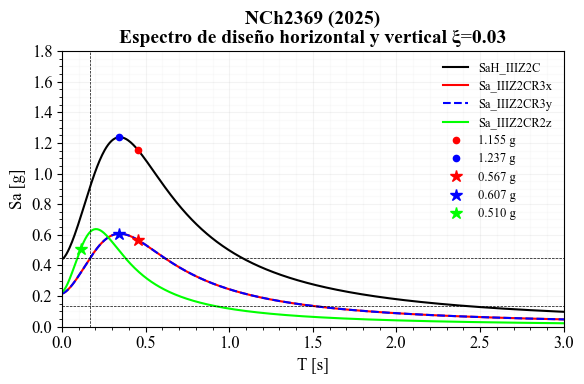

---------------------------------------------
Coef. sis. en x:	0.567 g (5.4.1a)
Coef. sis. en y:	0.607 g (5.4.1a)
Coef. sis. vertical:	0.510 g (5.4.1b)
Coef. sis. vertical_e:	0.635 g (5.7.1)
---------------------------------------------
Corte estr. en x:	166914.170 kgf
Corte estr. en y:	178637.287 kgf
Corte mínimo:		38948.791 kgf (5.12)
Corte máximo:		131391.167 kgf (5.13)
---------------------------------------------
FC corte máx. en x:	0.787
FC corte máx. en y:	0.736
FC desplazamientos:	2.038
---------------------------------------------
Corte final estr. x:	131391.167 kgf
Corte final estr. y:	131391.167 kgf


In [239]:
#Ejemplo de uso.
Coefimpo = 'III'
Zona = 'Z2'
Suelo = 'C'
Ro = 3
e = 0.03

T_est = [0.452661, 0.339372, 0.112742] #s
Ps = 294397.51 #kgf #modificiar este valor de acuerdo al obtenido en el analisis esrtructural.

esp_ = graf_espec(Coefimpo,Zona,Suelo, Ro, e, T_est, Ps, True) # [kgf] True: Se crea carpeta y se guardan los archivos .jpg y .txt

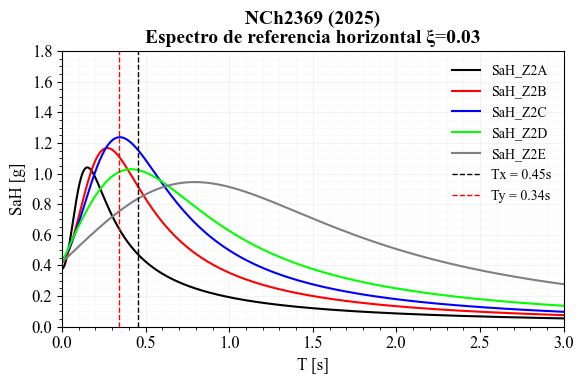

In [237]:
#GRAFICO ESPECTRO DE REFERENCIA GRUPO

TSuelo = 'A'; NCh2369_SA = NCh2369_2025(Coefimpo, Zona, TSuelo, Ro, e, T_est)
TSuelo = 'B'; NCh2369_SB = NCh2369_2025(Coefimpo, Zona, TSuelo, Ro, e, T_est)
TSuelo = 'C'; NCh2369_SC = NCh2369_2025(Coefimpo, Zona, TSuelo, Ro, e, T_est)
TSuelo = 'D'; NCh2369_SD = NCh2369_2025(Coefimpo, Zona, TSuelo, Ro, e, T_est)
TSuelo = 'E'; NCh2369_SE = NCh2369_2025(Coefimpo, Zona, TSuelo, Ro, e, T_est)

plt.figure(figsize=(6, 4), dpi = 100)

plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)

plt.title('NCh2369 (2025)\nEspectro de referencia horizontal {}={}'.format(chr(958),e), fontsize=14, fontweight='bold')
plt.xlabel('T [s]', fontsize=12)
plt.ylabel('SaH [g]', fontsize=12)

plt.plot(NCh2369_SA[0],NCh2369_SA[1],'-', alpha=1, linewidth=1.5, color='k', label = f'SaH_{Zona}A')
plt.plot(NCh2369_SB[0],NCh2369_SB[1],'-', alpha=1, linewidth=1.5, color='red', label = f'SaH_{Zona}B') 
plt.plot(NCh2369_SC[0],NCh2369_SC[1],'-', alpha=1, linewidth=1.5, color='blue', label = f'SaH_{Zona}C') 
plt.plot(NCh2369_SD[0],NCh2369_SD[1],'-', alpha=1, linewidth=1.5, color='lime', label = f'SaH_{Zona}D') 
plt.plot(NCh2369_SE[0],NCh2369_SE[1],'-', alpha=1, linewidth=1.5, color='gray', label = f'SaH_{Zona}E') 

plt.axvline(T_est[0], color='k', linestyle='--', linewidth=1, label = f'Tx = {T_est[0]:.2f}s')
plt.axvline(T_est[1], color='red', linestyle='--', linewidth=1, label = f'Ty = {T_est[1]:.2f}s')
#plt.axvline(T_est[2], color='lime', linestyle='--', linewidth=0.8)

plt.xlim(0,3)
major_ticks_top=np.linspace(0,3,7)
plt.xticks(major_ticks_top)

plt.ylim(0, 1.4)
major_ticks_top=np.linspace(0,1.8,10)
plt.yticks(major_ticks_top)

plt.legend(loc=1, fontsize=10, ncol=1, frameon=False)#, edgecolor='black', facecolor='white', borderaxespad=1)
plt.tight_layout()
plt.savefig((f"{Coefimpo}{Zona}{Suelo}R{Ro}")+'/'+f"SaH_{Zona}{Suelo}.jpg", dpi=800)
plt.show()